# 背景：变分自编码器 (VAE) 和证据下界 (ELBO)

在深入研究扩散模型之前，我们将首先介绍 **VAE（变分自编码器）** 作为入门知识。通过了解变分自编码器，您将学习使用**前向过程**/**反向过程**进行建模的基础知识。

自编码器是一种原始模型（神经网络），通过**编码器-解码器**模式来复制数据（例如图像），其中编码器将数据压缩到**潜在空间**(`latent space`)，解码器则从**潜在空间**重建数据。
在 VAE 中，使用**最优概率分布**来描述表示潜在空间的变量，而不是直接使用变量。VAE 被认为是**概率图**(`probabilistic graph`)或**变分贝叶斯**(`variational Bayesian`)的一部分。
通过这种方式，VAE 将无限接近图像的真实概率分布，对 VAE 抽取样本也将得到逼真的图像信息。

> 注意：[“模式识别与机器学习”](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf)（Christopher M. Bishop，Microsoft）中的第 10 章是理解变分贝叶斯的良好读物。
> 参阅[此处](https://github.com/tsmatz/gmm/)查看概率图中的变分贝叶斯 Python 示例。

---

## 架构 (Architecture)

在 VAE 中，我们假设生成图像的分布 $p(X)$（其中 $X=\{\mathbf{x}^{(i)}\}_{i=1}^N$ 是 $N$ 个观测数据点的集合）源自连续**潜在变量** $p(Z)$（其中 $Z=\{\mathbf{z}^{(i)}\}_{i=1}^N$ 是对应的潜在变量集合）。
然而，在这个问题中，**真实分布** $p(X)$ 和**隐藏数据点** $Z=\{\mathbf{z}^{(i)}\}_{i=1}^N$ 是未知且不可知的。因此，通过 **EM 算法**（似然方法）来解决这个问题是**难解的**。
因此，在 VAE 中，我们应用**变分贝叶斯**，通过假设一些**先验分布** $p(Z)$，来获得生成的图像和潜在变量之间的最优编码器/解码器。（参阅[此处](https://github.com/tsmatz/gmm/blob/master/02-gmm-variational-inference.ipynb)查看 GMM 示例中 EM 算法和变分贝叶斯的比较。）

为了澄清，这里我们将以手写数字图像（MNIST）为例向您展示。

![MNIST images](./assets/mnist_images.png)

首先，我们假设图像 $\mathbf{x}$（向量）是由某个**潜在变量** $\mathbf{z}$（向量）生成的。
例如，每个数字图像 $\mathbf{x}$（具有 $28 \times 28 = 786$ 维度）可能是通过某个数字生成的。在这种情况下，潜在变量 $\mathbf{z}$ 可以是离散的数字 0, 1, 2, ... , 9。

然而，用于生成图像的真实潜在空间可能是**连续的**，因此我们需要考虑**随机空间**。
例如，以下图像的潜在值可能位于数字 4 和 9 的中间。

![image either 4 or 9](./assets/mnist_4or9.png)

在我们的例子中，我们假设潜在先验分布为 $p(\mathbf{z}) = \mathcal{N}(\mathbf{0},\mathbf{I})$。（注意到：这里的先验分布 $p(\mathbf{z})$ 没有任何参数）

> 注意：实际上，**潜在空间的维度**应该足够大以表示完整的潜在空间。

我们假设一个值 $\mathbf{x}$ 是从某个**条件分布** $p_{\theta^{\ast}}(\mathbf{x}|\mathbf{z})$ 中生成的，其中 $p_{\theta}(\mathbf{x}|\mathbf{z})$ 是由参数 $\theta$ 构建的神经网络（或函数）确定，而 $\theta^{\ast}$ 表示最优参数。

在我们的例子中，我们假设 $p_{\theta}(\mathbf{x}|\mathbf{z})$ 也是一个**高斯分布** $p_{\theta}(\mathbf{x}|\mathbf{z}) = \mathcal{N}(\mu_{\theta}^{\verb|dec|}(\mathbf{z}),(\sigma^{\verb|dec|})^2)$，其中 $\sigma^{\verb|dec|}$ 是某个固定值。

例如，当潜在变量 $\mathbf{z}$ 代表数字 7 时，那么 $\mu_{\theta}^{\verb|dec|}(\mathbf{z})$ 将是代表数字 7 的向量图像。

我们还考虑一个**条件分布** $q_{\phi}(\mathbf{z}|\mathbf{x})$，该分布也由具有参数 $\phi$ 的神经网络（或函数）确定。
在我们的例子中，我们也假设 $q_{\phi}(\mathbf{z}|\mathbf{x})$ 是一个**高斯分布** $q_{\phi}(\mathbf{z}|\mathbf{x}) = \mathcal{N}(\mu_{\phi}^{\verb|enc|}(\mathbf{x}),\verb|diag|((\sigma_{\phi}^{\verb|enc|}(\mathbf{x}))^2))$。
例如，当图像向量 $\mathbf{x}$ 是上面的（数字 4 和 9 中间的数字图像）时，那么 $q_{\phi}(\mathbf{z}|\mathbf{x})$ 代表数字 4 和 9 中间的潜在分布。

$q_{\phi}(\mathbf{z}|\mathbf{x})$ 被称为**编码器 (encoder)**，而 $p_{\theta}(\mathbf{x}|\mathbf{z})$ 被称为**解码器 (decoder)**。

![VAE architecture](./assets/vae_architecture.png)

我们的目标是优化参数 $\phi$ 和 $\theta$，以最大化**对数似然** $\log p(\mathbf{x})$。

---

## 方法 (Method)

让我们简要地遵循原始论文 [[Diederik P. Kingma and Max Welling, 2013](https://arxiv.org/pdf/1312.6114)] 的方法来求解最优的 $\phi$ 和 $\theta$。

首先，观测值 $\log p(\mathbf{x})$ 的对数似然被分解为：

$\displaystyle \log p(\mathbf{x})$

$\displaystyle = \int \log p(\mathbf{x}) q_{\phi}(\mathbf{z}|\mathbf{x}) d\mathbf{z} $ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp; (因为 $\int q_{\phi}(\mathbf{z}|\mathbf{x}) d\mathbf{z} = 1$)

$\displaystyle = \mathbb{E}_{q_{\phi}(\mathbf{z}|\mathbf{x})}[\log p(\mathbf{x})] $

$\displaystyle = \mathbb{E}_{q_{\phi}(\mathbf{z}|\mathbf{x})}\left[\log \frac{p(\mathbf{x}, \mathbf{z})}{q_{\phi}(\mathbf{z}|\mathbf{x})}\right] + \mathbb{E}_{q_{\phi}(\mathbf{z}|\mathbf{x})}\left[\log\frac{q_{\phi}(\mathbf{z}|\mathbf{x})}{p(\mathbf{z}|\mathbf{x})}\right] $

$\displaystyle = \mathbb{E}_{q_{\phi}(\mathbf{z}|\mathbf{x})}\left[\log \frac{p(\mathbf{x}, \mathbf{z})}{q_{\phi}(\mathbf{z}|\mathbf{x})}\right] + D_{KL}\left(q_{\phi}(\mathbf{z}|\mathbf{x})\|p(\mathbf{z}|\mathbf{x})\right)$

其中 $p(\mathbf{z}|\mathbf{x})$ 是真实分布，$D_{KL}(q\|p)$ 是 $q$ 和 $p$ 之间的 **KL 散度**（Kullback-Leibler divergence）。

当 $q_{\phi}(\mathbf{z}|\mathbf{x})$ 趋近于真实分布时，$D_{KL}\left(q_{\phi}(\mathbf{z}|\mathbf{x})\|p(\mathbf{z}|\mathbf{x})\right)$ 趋近于零，因此 $\mathbb{E}_{q_{\phi}(\mathbf{z}|\mathbf{x})}\left[\log \frac{p(\mathbf{x}, \mathbf{z})}{q_{\phi}(\mathbf{z}|\mathbf{x})}\right]$ 是 $\log p(\mathbf{x})$ 的**下界**。

$\displaystyle \log p(\mathbf{x}) \geq \mathbb{E}_{q_{\phi}(\mathbf{z}|\mathbf{x})}\left[\log \frac{p(\mathbf{x}, \mathbf{z})}{q_{\phi}(\mathbf{z}|\mathbf{x})}\right]$

这个不等式右边的期望（下界）被称为 **证据下界 (Evidence Lower Bound, ELBO)**（参阅[此处](https://github.com/tsmatz/gmm/blob/master/02-gmm-variational-inference.ipynb)），我们的目标是最大化这个下界，以便在观测数据点 $\{\mathbf{x}^{(i)}\}_{i=1}^N$ 上最大化 $\log p(\mathbf{x})$。

因为 $p(\mathbf{x}, \mathbf{z}) = p(\mathbf{x}|\mathbf{z}) p(\mathbf{z})$，证据下界 (`ELBO`) 可以分解如下：

$\displaystyle \mathbb{E}_{q_{\phi}(\mathbf{z}|\mathbf{x})}\left[\log \frac{p(\mathbf{x}, \mathbf{z})}{q_{\phi}(\mathbf{z}|\mathbf{x})}\right] = \mathbb{E}_{q_{\phi}(\mathbf{z}|\mathbf{x})}[\log p_{\theta}(\mathbf{x}|\mathbf{z})] - D_{KL} \left( q_{\phi}(\mathbf{z}|\mathbf{x}) \| p(\mathbf{z}) \right)$

第二项（KL 散度项）$D_{KL} \left( q_{\phi}(\mathbf{z}|\mathbf{x}) \| p(\mathbf{z}) \right)$ 表示分布 $q_{\phi}(\mathbf{z}|\mathbf{x})$ 与边缘分布 $p(\mathbf{z})$ 的相似程度，并且由于在本示例中 $q_{\phi}(\mathbf{z}|\mathbf{x})$ 和 $p(\mathbf{z})$ 的形式都是**已知的高斯分布**，因此可以很容易地进行积分求解。（参见下面实现中的描述。）

对于第一项 $\mathbb{E}_{q_{\phi}(\mathbf{z}|\mathbf{x})}[\log p_{\theta}(\mathbf{x}|\mathbf{z})]$，我们应该在给定输入 $\mathbf{x}$ 的情况下最大化概率 $p_{\theta}(\mathbf{x}|\mathbf{z})$，这个等同于最小化**重建图像** $\hat{\mathbf{x}}$（即 $\mu_{\theta}^{\verb|dec|}(\mathbf{z})$）与输入图像 $\mathbf{x}$ 之间的差异。
在实践中，这种期望计算需要通过从 $q_{\phi}(\mathbf{z}|\mathbf{x})$ **采样**来估计：

$\displaystyle \mathbb{E}_{q_{\phi}(\mathbf{z}|\mathbf{x})}[\log p_{\theta}(\mathbf{x}|\mathbf{z})] \simeq \frac{1}{M} \sum_{i=1}^M \left( \frac{1}{L} \sum_{l=1}^L \left( \log p_{\theta}(\mathbf{x}^{(i)} | \mathbf{z}^{(i,l)}) \right) \right)$

其中 $M$ 是小批量 $\{\mathbf{x}^{(i)}\}_{i=1}^M$ 的数量，$L$ 是在每个 $\mathbf{x}^{(i)}$ 中从 $\mathbf{z}^{(i,l)} \sim q_{\phi}(\mathbf{z}|\mathbf{x^{(i)}})$ 采样的数量。

但是优化该项是不可解的，因为 $q_{\phi}(\mathbf{z}|\mathbf{x})$ 依赖于需要优化的参数 $\phi$，然而梯度下降算法中计算采样过程的梯度 $\nabla_{\phi}\mathbb{E}_{q_{\phi}(\mathbf{z}|\mathbf{x})}[\cdot]$ 是**难解的**。

为了解决这个问题，我们应用**重参数化 (reparameterization) 技巧**（改变求解参数），如下所示。

设 $\mathbf{z}$ 是一个连续随机变量，且 $\mathbf{z} \sim q_{\phi}(\mathbf{z}|\mathbf{x})$，我们假设 $\mathbf{z}$ 可以表示为 $\mathbf{z} = g_{\phi}(\epsilon, \mathbf{x})$，其中 $\epsilon \sim p(\epsilon)$ 是**独立于参数 $\phi$** 的分布，而 $g_{\phi}(\cdot)$ 是由 $\phi$ 参数化的某个向量值函数。
在这个假设下，我们还假设区间满足 $q_{\phi}(\mathbf{z}|\mathbf{x}) dz_0 dz_1 \ldots dz_{n-1} = p(\epsilon) d\epsilon_0 d\epsilon_1 \ldots d\epsilon_{n-1}$，其中 $\mathbf{z} = (z_0, z_1, \ldots, z_{n-1})$ 且 $\epsilon = (\epsilon_0, \epsilon_1, \ldots, \epsilon_{n-1})$。

> 注意：在这种情况下，它也满足 $q_{\phi}(\mathbf{x}|\mathbf{z}) \cdot \left| \det \left( \frac{\partial \mathbf{z}}{\partial \mathbf{\epsilon}} \right) \right| = p(\mathbf{\epsilon})$，其中 $\frac{\partial \mathbf{z}}{\partial \mathbf{\epsilon}}$ 是雅可比行列式 (Jacobian)。(这是一个对偶条件。)
> 参阅[此处](https://tutorial.math.lamar.edu/classes/calciii/changeofvariables.aspx)了解变量变化和雅可比行列式。

在我们的例子中，分布 $q_{\phi}(\mathbf{z}|\mathbf{x})$ 是 $\mathcal{N}(\mu_{\phi}^{\verb|enc|}(\mathbf{x}),\verb|diag|((\sigma_{\phi}^{\verb|enc|}(\mathbf{x}))^2))$（见上文），然后我们可以定义 $p(\epsilon)$ 和 $g_{\phi}(\epsilon, \mathbf{x})$ 以满足上述条件，如下所示：

---

**重参数化 (reparameterization)**

$$\displaystyle \mathbf{z} = g_{\phi}(\epsilon, \mathbf{x}) \stackrel{\mathrm{def}}{=} \mu_{\phi}^{\verb|enc|}(\mathbf{x}) + \verb|diag|(\sigma_{\phi}^{\verb|enc|}(\mathbf{x})) \odot \epsilon$$

其中 $\epsilon \sim \mathcal{N}(\mathbf{0},\mathbf{I})$，第二项 $\verb|diag|(\sigma_{\phi}^{\verb|enc|}(\mathbf{x})) \odot \epsilon$ 表示 $\sigma_{\phi}^{\verb|enc|}(\mathbf{x})$ 的对角元素与向量 $\epsilon$ 之间的**元素级乘法**。

---


在这个假设下，我们可以通过采样构建**可微分的估计器**，因为以下等式成立：

$\displaystyle \mathbb{E}_{q_{\phi}(\mathbf{z}|\mathbf{x})}[f(\mathbf{z})]$

$\displaystyle =\int q_{\phi}(\mathbf{z}|\mathbf{x}) f(\mathbf{z}) d \mathbf{z}$

$\displaystyle =\int p(\epsilon) f(\mathbf{z}) d \epsilon$

$\displaystyle =\int p(\epsilon) f(g_{\phi}(\epsilon, \mathbf{x})) d \epsilon$

$\displaystyle =\mathbb{E}_{p(\epsilon)}[f(g_{\phi}(\epsilon, \mathbf{x}))]$

现在，我们可以通过梯度法最小化重建图像 $\hat{\mathbf{x}}$（即 $\mu_{\theta}^{\verb|dec|}(\mathbf{z})$）与输入图像 $\mathbf{x}$ 之间的差异，然后最终通过优化 $\phi$ 和 $\theta$ 来最大化上述 **ELBO（证据下界）**。

---

## 实现 (Implementation)

### 构建和训练 VAE (Build and train VAE)

在开始之前，我们需要安装所需的软件包。

In [7]:
!pip install torch torchvision matplotlib

我们加载手写数字图像（MNIST）数据集和数据加载器。
每个批次形状为 `[batch_size, 1, 28, 28]`。

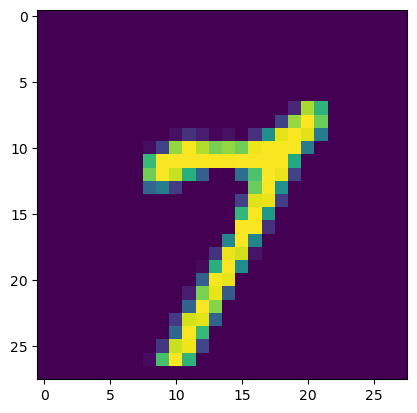

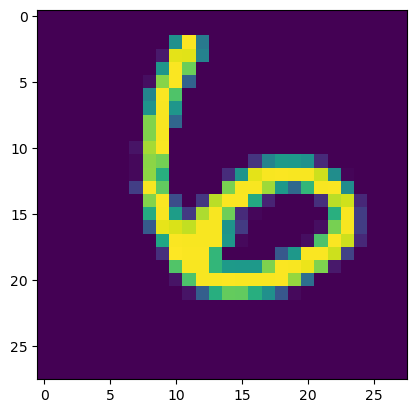

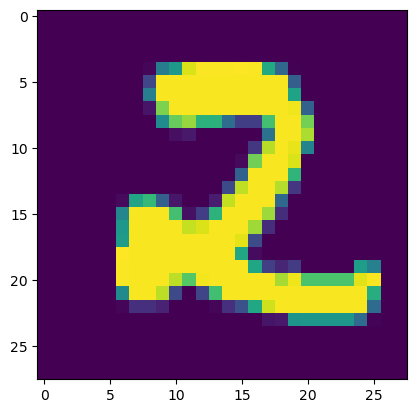

In [9]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

batch_size = 100

dataset = datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transforms.Compose([transforms.ToTensor()]))

loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

# show examples
for _, (data, _) in enumerate(loader):
    images = data[:3]
    break
for i in images:
    plt.imshow(i[0].numpy())
    plt.show()

现在我们构建一个**编码器网络**，它在以下分布中输出 $\mu_{\phi}^{\verb|enc|}(\mathbf{x})$ 和 $\verb|diag|((\sigma_{\phi}^{\verb|enc|}(\mathbf{x}))^2)$ 中的对角元素。

$q_{\phi}(\mathbf{z}|\mathbf{x}) = \mathcal{N}(\mu_{\phi}^{\verb|enc|}(\mathbf{x}),\verb|diag|((\sigma_{\phi}^{\verb|enc|}(\mathbf{x}))^2))$

In [11]:
import torch.nn as nn
from torch.nn import functional as F

latent_dim = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class EncoderNet(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        cur_dim = 64 * 7 * 7
        self.fc_mean = nn.Linear(cur_dim, latent_dim)
        self.fc_logvar = nn.Linear(cur_dim, latent_dim)

    def forward(self, x):
        x = self.conv1(x)       # --> size [batch_size, 32, 14, 14]
        x = F.relu(x)
        x = self.conv2(x)       # --> size [batch_size, 64, 7, 7]
        x = F.relu(x)
        x = torch.flatten(x, 1) # --> size [batch_size, 64*7*7]

        mean = self.fc_mean(x)
        logvar = self.fc_logvar(x)
        return mean, logvar

#
# Generate a model for encoder distribution
#
encoder_net = EncoderNet(latent_dim=latent_dim).to(device)

我们也构建一个**解码器网络**。
如上所示，$p_{\theta}(\mathbf{x}|\mathbf{z}) = \mathcal{N}(\mu_{\theta}^{\verb|dec|}(\mathbf{z}),(\sigma^{\verb|dec|})^2)$（其中 $\sigma$ 是某个常数），我们只需要在这个网络中获取**均值**。

In [13]:
class DecoderNet(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.projection = nn.Linear(latent_dim, 64 * 7 * 7)
        self.convtrans1 = nn.ConvTranspose2d(64, 64, kernel_size=3, stride=2)
        self.convtrans2 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2)
        self.convtrans3 = nn.ConvTranspose2d(32, 1, kernel_size=3, stride=1)

    def forward(self, x):
        x = self.projection(x)               # --> size [batch_size, 64*7*7]
        x = torch.reshape(x, (-1, 64, 7, 7)) # --> size [batch_size, 64, 7, 7]
        x = self.convtrans1(x)               # --> size [batch_size, 64, 15, 15]
        x = x[:,:,:-1,:-1]                   # --> size [batch_size, 64, 14, 14] (cropping)
        x = F.relu(x)
        x = self.convtrans2(x)               # --> size [batch_size, 32, 29, 29]
        x = x[:,:,:-1,:-1]                   # --> size [batch_size, 32, 28, 28] (cropping)
        x = F.relu(x)
        x = self.convtrans3(x)               # --> size [batch_size, 1, 30, 30]
        x = x[:,:,:-2,:-2]                   # --> size [batch_size, 1, 28, 28] (cropping)
        return torch.sigmoid(x)

#
# Generate a decoder model
#
decoder_net = DecoderNet(latent_dim=latent_dim).to(device)

我们计算 **KL 散度 (KL-loss)**：$D_{KL} \left( q_{\phi}(\mathbf{z}|\mathbf{x}) \| p(\mathbf{z}) \right)$。

该值可以通过解析计算得出，如下所示。（参阅[原论文](https://arxiv.org/pdf/1312.6114)中的“附录 B”。）

$\displaystyle D_{KL} \left( q_{\phi}(\mathbf{z}|\mathbf{x}) \| p(\mathbf{z}) \right)$

$\displaystyle = \int q_{\phi}(\mathbf{z}|\mathbf{x}) \log q_{\phi}(\mathbf{z}|\mathbf{x}) d\mathbf{z} - \int q_{\phi}(\mathbf{z}|\mathbf{x}) \log p(\mathbf{z}) d\mathbf{z} $

$\displaystyle = \int \mathcal{N}(\mu(\phi),\verb|diag|(\sigma(\phi)^2)) \log \mathcal{N}(\mu(\phi),\verb|diag|(\sigma(\phi)^2)) d\mathbf{z} - \int \mathcal{N}(\mu(\phi),\verb|diag|(\sigma(\phi)^2)) \log \mathcal{N}(\mathbf{0},\mathbf{I}) d\mathbf{z} $

$\displaystyle = \left( -\frac{J}{2} \log(2\pi) - \frac{1}{2} \sum_{j=1}^J (1 + \log (\sigma(\phi)_j^2)) \right) - \left( -\frac{J}{2} \log(2\pi) - \frac{1}{2} \sum_{j=1}^J (\mu(\phi)_j^2 + \sigma(\phi)_j^2) \right)$

$\displaystyle = -\frac{1}{2} \sum_{j=1}^J \left( 1 + \log (\sigma(\phi)_j^2) - \mu(\phi)_j^2 - \sigma(\phi)_j^2 \right)$

其中 $J$ 是潜在空间 $\mathbf{z}$ 的维度，$\mu(\phi)_j$、$\sigma(\phi)_j$ 是每个向量的第 $j$ 个元素。

In [15]:
def kl(mean, logvar):
    elements = logvar + 1.0 - mean**2 - torch.exp(logvar)
    return torch.sum(elements, dim=-1) * (-0.5)

通过应用**重参数化**，从 $q_{\phi}(\mathbf{z}|\mathbf{x})$ 获取样本，如下所示：

$$\displaystyle \mathbf{z} = \mu_{\phi} + \sigma_{\phi}^{\verb|diag|} \odot \epsilon$$

其中 $\epsilon \sim \mathcal{N}(\mathbf{0},\mathbf{I})$，$\sigma_{\phi}^{\verb|diag|} \odot \epsilon$ 表示 $\sigma_{\phi}^{\verb|diag|}$（$\sigma_{\phi}$ 的对角元素）与 $\epsilon$ 之间的**元素级乘法**。

In [17]:
# expand tensor, such as : [batch_size, latent_dim] --> [batch_size * num_sampling, latent_dim]
def expand_for_sampling(x, num_sampling):
    latent_dim = x.shape[1]

    x_sampling = x.unsqueeze(dim=1)
    x_sampling = x_sampling.expand(-1, num_sampling, -1)
    return torch.reshape(x_sampling, (-1, latent_dim))

def reparameter_sampling(mean, logvar, num_sampling):
    # expand mean : [batch_size, latent_dim] --> [batch_size * num_sampling, latent_dim]
    mean_sampling = torch.repeat_interleave(mean, num_sampling, dim=0)

    # expand logvar : [batch_size, latent_dim] --> [batch_size * num_sampling, latent_dim]
    logvar_sampling = torch.repeat_interleave(logvar, num_sampling, dim=0)

    # get epsilon
    epsilon_sampling = torch.randn_like(mean_sampling).to(device)

    return torch.mul(torch.exp(logvar_sampling * 0.5), epsilon_sampling) + mean_sampling

现在我们训练模型以优化 $\phi$ 和 $\theta$。

正如[此处](https://tsmatz.wordpress.com/2017/08/30/regression-in-machine-learning-math-for-beginners/)提到的，高斯分布中的对数似然等同于 **MSE（均方误差）损失**。因此，您也可以使用 **MSE 损失函数**来代替使用 `gaussian_nll_loss()`，但在这种情况下，请注意**重建损失和 KL 损失之间的比例**。

In [19]:
num_sampling = 5     # the number of sampling
num_epochs = 20

opt = torch.optim.AdamW(list(encoder_net.parameters()) + list(decoder_net.parameters()), lr=0.001)

loss_records = []
for epoch_idx in range(num_epochs):
    for batch_idx, (data, _) in enumerate(loader):
        x = data.to(device)

        opt.zero_grad()

        # get mean and logvar
        z_mean, z_logvar = encoder_net(x)
    
        # get KL-div (KL loss)
        kl_loss_batch = kl(z_mean, z_logvar) # shape: [batch_size,]
        kl_loss = torch.sum(kl_loss_batch)
    
        # sampling by reparameterization
        z_samples = reparameter_sampling(z_mean, z_logvar, num_sampling)
    
        # reconstruct x by decoder
        decoded_x_samples = decoder_net(z_samples)
        decoded_x_samples = torch.reshape(decoded_x_samples, (-1, 28*28))
    
        # get BCE loss between the input x and the reconstructed x
        x_samples = torch.repeat_interleave(x, num_sampling, dim=0)  # expand to shape: [batch_size * num_sampling, 1, 28, 28]
        x_samples = torch.reshape(x_samples, (-1, 28*28))
        pvar = torch.ones_like(x_samples).to(device) * 0.25  # sharp fit (p(x)_sigma=0.5)
        # pvar = torch.ones_like(x_samples).to(device) * 1.00  # loose fit (p(x)_sigma=1.0)
        reconstruction_loss = F.gaussian_nll_loss(
            decoded_x_samples,
            x_samples,
            var=pvar,
            reduction="sum"
        )
        reconstruction_loss /= num_sampling
        ########## for debug
        # if batch_idx == 0:
        #     print(reconstruction_loss)
        #     print(kl_loss)
    
        # optimize parameters
        total_loss = reconstruction_loss + kl_loss
        total_loss.backward()
        opt.step()
    
        # log
        loss_records.append(total_loss.item())
        print("epoch{} (iter{}) - loss {:5.4f}".format(epoch_idx, batch_idx, total_loss), end="\r")

    epoch_loss_all = loss_records[-(batch_idx+1):]
    average_loss = sum(epoch_loss_all)/len(epoch_loss_all)
    print("epoch{} (iter{}) - loss {:5.4f}".format(epoch_idx, batch_idx, average_loss))

print("Done")

epoch0 (iter599) - loss -47509.8197
epoch1 (iter599) - loss -49655.2759
epoch2 (iter599) - loss -49841.1827
epoch3 (iter599) - loss -49939.4187
epoch4 (iter599) - loss -50008.7326
epoch5 (iter599) - loss -50066.2745
epoch6 (iter599) - loss -50108.4596
epoch7 (iter599) - loss -50144.6372
epoch8 (iter599) - loss -50178.1638
epoch9 (iter599) - loss -50204.4040
epoch10 (iter599) - loss -50230.7596
epoch11 (iter599) - loss -50251.9761
epoch12 (iter599) - loss -50273.0480
epoch13 (iter599) - loss -50291.8001
epoch14 (iter599) - loss -50307.1635
epoch15 (iter599) - loss -50323.8589
epoch16 (iter599) - loss -50334.7162
epoch17 (iter599) - loss -50350.6128
epoch18 (iter599) - loss -50359.6734
epoch19 (iter599) - loss -50371.9216
Done


训练完成后，显示损失以查看训练进度。

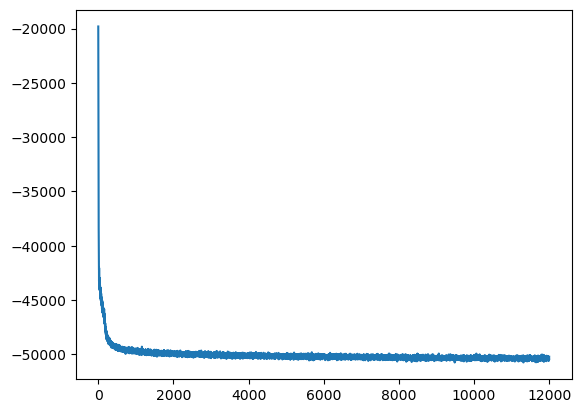

In [21]:
plt.plot(loss_records)

### 生成图像 (Generate images)

使用训练好的模型，让我们从随机潜在向量生成图像。（这里我生成 5 个潜在向量。）

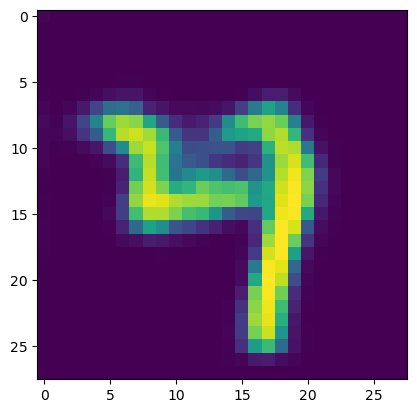

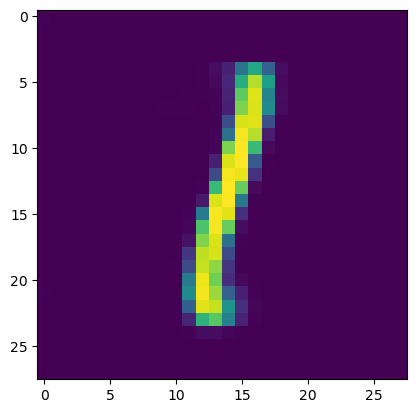

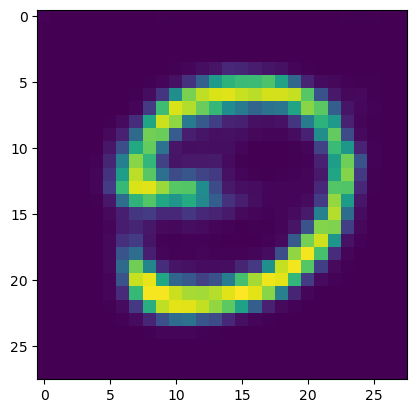

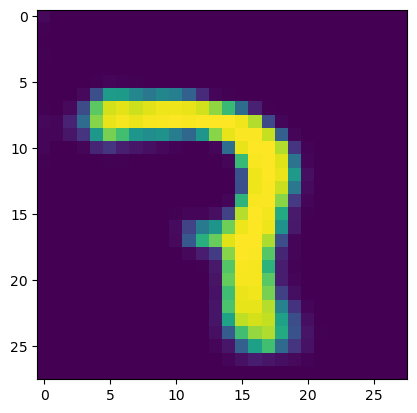

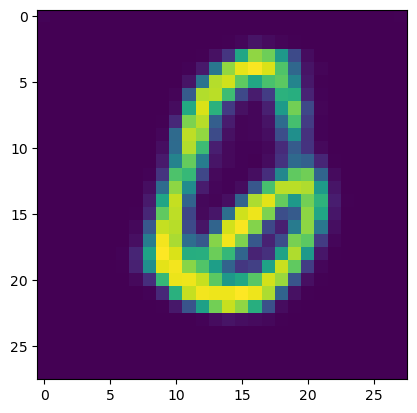

In [23]:
import matplotlib.pyplot as plt

latent_samples = torch.randn(5, latent_dim).to(device)
with torch.no_grad():
    imgs = decoder_net(latent_samples)
for i in imgs:
    plt.imshow(i[0].cpu().numpy())
    plt.show()

您还可以将变分自编码器 (VAE) 应用于各种任务——例如**去噪**、**异常检测**等。

这里我简单地通过应用编码/解码来恢复**无噪声图像**。
> 注意：要构建用于去噪的模型，请使用**去噪数据集**（即噪声图像和干净图像的对），并使用 VAE 架构训练模型进行去噪。（这里我只是简单地重用上面的模型来恢复干净图像。）

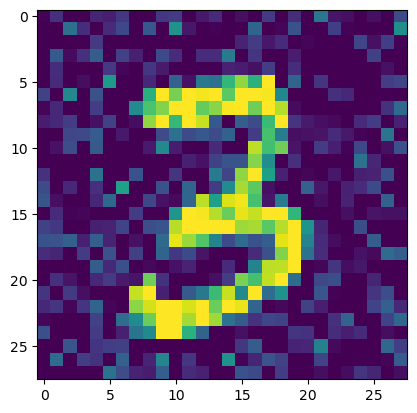

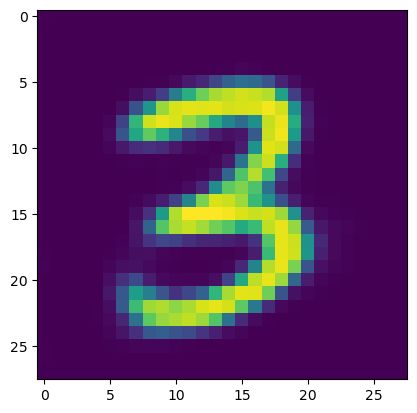

In [25]:
# make noisy image
noise_factor = 0.2
for _, (data, _) in enumerate(loader):
    data = data.to(device)
    org_image = data[0]
    noisy_image = org_image + noise_factor * torch.randn_like(org_image)
    noisy_image = torch.clamp(noisy_image, min=0.0, max=1.0)
    break

# show noisy image
plt.imshow(noisy_image[0].cpu().numpy())
plt.show()

# recover thru encoder/decoder
with torch.no_grad():
    mu, sigma = encoder_net(noisy_image.unsqueeze(dim=0))
    decoded_image = decoder_net(mu)

# show the recovered image
plt.imshow(decoded_image[0][0].cpu().numpy())
plt.show()